# Synthetic results

This notebook reports the completed primary DVFM-only synthetic experiment from `results/synthetic/`. It requires the run success marker and reads the raw prediction, latent-diagnostic, and run-manifest artifacts directly.

The main figure addresses four claims: individual frailty recovery, Kendall's $\tau$ calibration, joint-survival recovery, and predictive benefit over the $z=0$ ablation. Panel A omits $\tau=0$ because subject-level frailty recovery is undefined when the DGP has no shared-frailty signal. Panel B reports signed conditional-dependence error, $\hat{\tau}-\tau$, for DVFM-z1; zero is perfect calibration, positive values are overestimates, and negative values are underestimates. It does not plot latent-$z$ values. Panels C and D are paired z0-minus-z1 improvements, so values above zero favor the shared-latent model.

In [9]:
from pathlib import Path
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
tex_setting = os.environ.get("DVFM_USE_TEX", "auto").lower()
USE_TEX = tex_setting in {"1", "true", "yes"} or (tex_setting == "auto" and shutil.which("latex") is not None)
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 14.0,
    "legend.fontsize": "medium",
    "text.usetex": USE_TEX,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
})

ROOT = Path.cwd()
if not (ROOT / "configs" / "synthetic.yaml").exists():
    ROOT = ROOT.parent
RESULT_DIR = ROOT / "results" / "synthetic"
FIGURE_DIR = ROOT / "paper" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"LaTeX rendering: {USE_TEX}; result directory: {RESULT_DIR}")

LaTeX rendering: True; result directory: c:\Users\cml\Desktop\dvfm-survival\results\synthetic


In [10]:
def _primary_dvfm_rows(frame):
    out = frame[frame["model"].astype(str).str.lower().eq("dvfm")].copy()
    out = out[out["is_primary_checkpoint"].astype(str).str.lower().eq("true")]
    if "prediction_mode" in out:
        out = out[out["prediction_mode"].astype(str).str.lower().eq("prior")]
    return out

raw_path = RESULT_DIR / "results_raw.csv"
diagnostic_path = RESULT_DIR / "dvfm_diagnostics.csv"
manifest_path = RESULT_DIR / "run_manifest.csv"
required = [RESULT_DIR / "_SUCCESS", raw_path, diagnostic_path, manifest_path]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Synthetic run is incomplete; missing: " + ", ".join(missing))

manifest = pd.read_csv(manifest_path)
failures = manifest[~manifest["status"].eq("success")]
if not failures.empty:
    raise RuntimeError(f"Synthetic run contains {len(failures)} failed fits")
raw = _primary_dvfm_rows(pd.read_csv(raw_path))
diagnostics = _primary_dvfm_rows(pd.read_csv(diagnostic_path))
diagnostics = diagnostics[pd.to_numeric(diagnostics["latent_dim"], errors="coerce").eq(1)].copy()
if len(manifest) != 240 or len(raw) != 240 or len(diagnostics) != 360:
    raise RuntimeError(
        f"Unexpected artifact sizes: manifest={len(manifest)}, raw={len(raw)}, "
        f"z1 diagnostics={len(diagnostics)}"
    )
print(
    "COMPLETED SYNTHETIC RESULTS",
    f"| fits={len(manifest):,}, primary-prior rows={len(raw):,}, z1 diagnostics={len(diagnostics):,}",
)

COMPLETED SYNTHETIC RESULTS | fits=240, primary-prior rows=240, z1 diagnostics=360


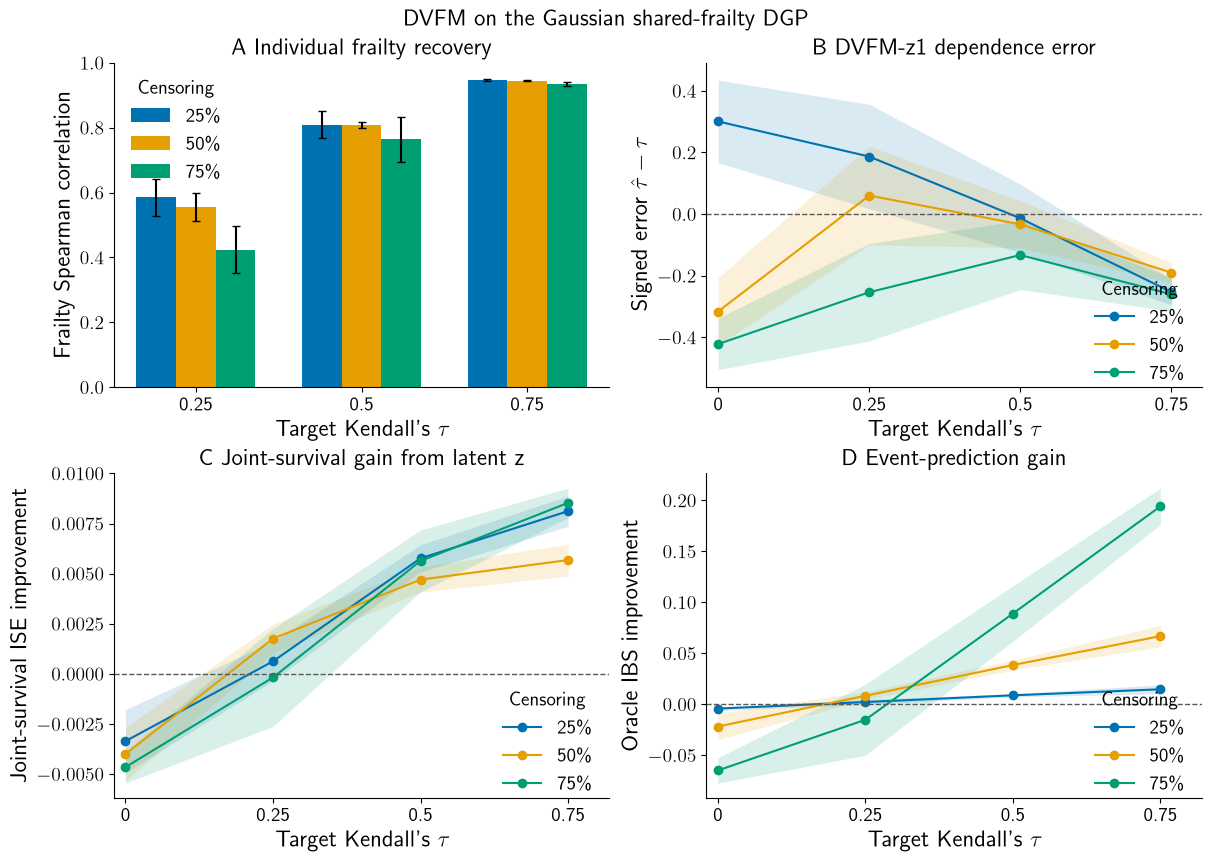

Wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_main.pdf


In [11]:
def mean_ci(frame, groups, metric):
    out = frame.groupby(groups)[metric].agg(["mean", "std", "count"]).reset_index()
    out["ci95"] = 1.96 * out["std"].fillna(0) / np.sqrt(out["count"].clip(lower=1))
    return out

z1 = raw[pd.to_numeric(raw["latent_dim"], errors="coerce").eq(1)].copy()
frailty_all = diagnostics[diagnostics["subgroup"].eq("all")].copy()
frailty_summary = mean_ci(frailty_all, ["target_kendall_tau", "target_censoring_rate"], "frailty_spearman")
frailty_summary = frailty_summary[frailty_summary["target_kendall_tau"].gt(0)].copy()
tau_summary = mean_ci(z1, ["target_kendall_tau", "target_censoring_rate"], "conditional_kendall_tau_error")
joint_wide = raw.pivot_table(index=["repeat", "target_kendall_tau", "target_censoring_rate"], columns="latent_dim", values="oracle_joint_survival_ise").reset_index()
joint_wide["joint_ise_gain"] = joint_wide[0] - joint_wide[1]
joint_summary = mean_ci(joint_wide, ["target_kendall_tau", "target_censoring_rate"], "joint_ise_gain")

ibs_wide = raw.pivot_table(index=["repeat", "target_kendall_tau", "target_censoring_rate"], columns="latent_dim", values="oracle_ibs").reset_index()
ibs_wide["oracle_ibs_gain"] = ibs_wide[0] - ibs_wide[1]
gain_summary = mean_ci(ibs_wide, ["target_kendall_tau", "target_censoring_rate"], "oracle_ibs_gain")

fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.5), constrained_layout=True)
colors = dict(zip((0.25, 0.50, 0.75), ("#0072B2", "#E69F00", "#009E73")))
tau_ticks = np.array([0.0, 0.25, 0.5, 0.75])
tau_tick_labels = ["0", "0.25", "0.5", "0.75"]
frailty_taus = np.sort(frailty_summary["target_kendall_tau"].unique())
bar_x = np.arange(len(frailty_taus), dtype=float)
bar_width = 0.24
for offset, (censoring, part) in zip((-bar_width, 0.0, bar_width), frailty_summary.groupby("target_censoring_rate")):
    part = part.set_index("target_kendall_tau").loc[frailty_taus]
    axes[0, 0].bar(bar_x + offset, part["mean"], width=bar_width, yerr=part["ci95"], capsize=3, color=colors[censoring], label=rf"{100*censoring:.0f}\%")
axes[0, 0].set_xticks(bar_x, [f"{tau:g}" for tau in frailty_taus])
axes[0, 0].set(title=r"A  Individual frailty recovery", xlabel=r"Target Kendall's $\tau$", ylabel="Frailty Spearman correlation", ylim=(0, 1))
axes[0, 0].legend(title="Censoring", loc="upper left", frameon=False)

for censoring, part in tau_summary.groupby("target_censoring_rate"):
    part = part.sort_values("target_kendall_tau")
    x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "ci95"))
    axes[0, 1].fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
    axes[0, 1].plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
axes[0, 1].axhline(0, color="0.35", linestyle="--", linewidth=1)
tau_low = min(0.0, float((tau_summary["mean"] - tau_summary["ci95"]).min()))
tau_high = max(0.0, float((tau_summary["mean"] + tau_summary["ci95"]).max()))
tau_pad = 0.06 * (tau_high - tau_low)
axes[0, 1].set(title=r"B  DVFM-z1 dependence error", xlabel=r"Target Kendall's $\tau$", ylabel=r"Signed error $\hat{\tau}-\tau$", xlim=(-0.02, 0.80), ylim=(tau_low - tau_pad, tau_high + tau_pad))
axes[0, 1].set_xticks(tau_ticks, tau_tick_labels)
axes[0, 1].legend(title="Censoring", loc="lower right", frameon=False, bbox_to_anchor=(1.0, -0.04))

for censoring, part in joint_summary.groupby("target_censoring_rate"):
    part = part.sort_values("target_kendall_tau")
    x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "ci95"))
    axes[1, 0].fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
    axes[1, 0].plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
axes[1, 0].axhline(0, color="0.35", linestyle="--", linewidth=1)
axes[1, 0].set(title="C  Joint-survival gain from latent z", xlabel=r"Target Kendall's $\tau$", ylabel="Joint-survival ISE improvement", xlim=(-0.02, 0.82))
axes[1, 0].set_xticks(tau_ticks, tau_tick_labels)
axes[1, 0].legend(title="Censoring", loc="lower right", frameon=False, bbox_to_anchor=(1.0, -0.04))

for censoring, part in gain_summary.groupby("target_censoring_rate"):
    part = part.sort_values("target_kendall_tau")
    x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "ci95"))
    axes[1, 1].fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
    axes[1, 1].plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
axes[1, 1].axhline(0, color="0.35", linestyle="--", linewidth=1)
axes[1, 1].set(title="D  Event-prediction gain", xlabel=r"Target Kendall's $\tau$", ylabel="Oracle IBS improvement", xlim=(-0.02, 0.82))
axes[1, 1].set_xticks(tau_ticks, tau_tick_labels)
axes[1, 1].legend(title="Censoring", loc="lower right", frameon=False, bbox_to_anchor=(1.0, -0.04))
fig.suptitle("DVFM on the Gaussian shared-frailty DGP", fontweight="bold")
out = FIGURE_DIR / "synthetic_main.pdf"
fig.savefig(out)
plt.show()
print(f"Wrote {out}")

## Appendix diagnostic: recovery by observed subgroup

This separates all test subjects, observed-event subjects, and censored subjects. The primary paper should use the compact all-subject curve above unless subgroup differences are scientifically important.

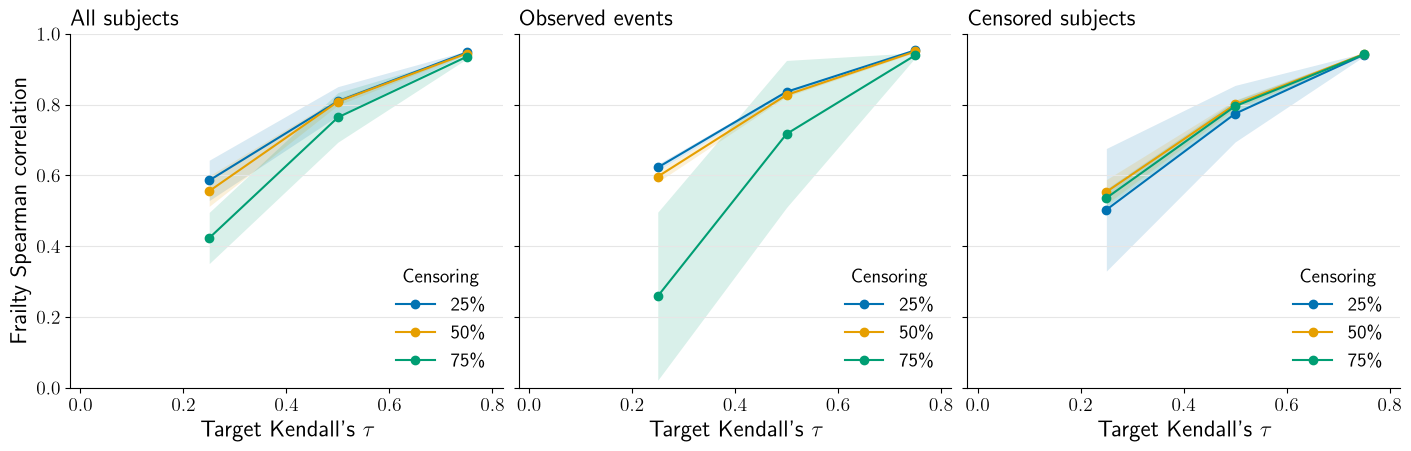

Wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\synthetic_frailty_subgroups.pdf


In [12]:
labels = {"all": "All subjects", "event_observed": "Observed events", "censored": "Censored subjects"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharex=True, sharey=True, constrained_layout=True)
for ax, subgroup in zip(axes, labels):
    subgroup_rows = diagnostics[diagnostics["subgroup"].eq(subgroup) & diagnostics["target_kendall_tau"].gt(0)]
    summary = mean_ci(subgroup_rows, ["target_kendall_tau", "target_censoring_rate"], "frailty_spearman")
    for censoring, part in summary.groupby("target_censoring_rate"):
        part = part.sort_values("target_kendall_tau")
        x, mean, ci = (part[name].to_numpy(dtype=float) for name in ("target_kendall_tau", "mean", "ci95"))
        ax.fill_between(x, mean - ci, mean + ci, color=colors[censoring], alpha=0.15, linewidth=0)
        ax.plot(x, mean, marker="o", color=colors[censoring], label=rf"{100*censoring:.0f}\%")
    ax.set_title(labels[subgroup], loc="left", fontweight="bold")
    ax.set_xlabel(r"Target Kendall's $\tau$")
    ax.set_xlim(-0.02, 0.82)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.legend(title="Censoring", loc="lower right", frameon=False)
axes[0].set_ylabel("Frailty Spearman correlation")
out = FIGURE_DIR / "synthetic_frailty_subgroups.pdf"
fig.savefig(out)
plt.show()
print(f"Wrote {out}")